# Projet de classification d'images : MLP et CNN (CIFAR-10)

> Notebook pensé pour **Google Colab** avec téléchargement des données depuis le site officiel de Toronto.

## Objectifs
- Télécharger et préparer CIFAR-10 depuis la source officielle.
- Entraîner un modèle **MLP** de référence.
- Entraîner un modèle **CNN** plus performant.
- Comparer les performances et analyser les résultats.

In [3]:
import os
import sys

# 1. On vérifie si on est sur Colab
if 'google.colab' in sys.modules:
    # 2. On clone le repo directement dans l'espace temporaire de la VM (/content)
    # On vérifie si le dossier existe déjà pour éviter les erreurs en cas de réexécution
    if not os.path.exists('/content/neuralzoo'):
        !git clone https://github.com/bruno-coulet/neuralzoo.git

    # 3. On se déplace dans le dossier du projet
    %cd /content/neuralzoo

    # 4. On ajoute la racine au sys.path pour que 'import src' fonctionne
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())

print(f"Dossier actuel : {os.getcwd()}")
# Vérification que 'src' est visible
!ls src/

Cloning into 'neuralzoo'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 87 (delta 35), reused 73 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 7.21 MiB | 11.86 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/neuralzoo
Dossier actuel : /content/neuralzoo
app.py	heuristic.py  __init__.py  model.py


In [5]:
# Imports
from __future__ import annotations

from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Export des models
import os, sys
# from src.model import save_trained_model

In [6]:
# 1. On vérifie si on est sur Colab
if 'google.colab' in sys.modules:
    # 2. On clone le repo directement dans l'espace temporaire de la VM (/content)
    # On vérifie si le dossier existe déjà pour éviter les erreurs en cas de réexécution
    if not os.path.exists('/content/neuralzoo'):
        !git clone https://github.com/bruno-coulet/neuralzoo.git

    # 3. On se déplace dans le dossier du projet
    %cd /content/neuralzoo

    # 4. On ajoute la racine au sys.path pour que 'import src' fonctionne
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())

print(f"Dossier actuel : {os.getcwd()}")
# Vérification que 'src' est visible
!ls src/

/content/neuralzoo
Dossier actuel : /content/neuralzoo
app.py	heuristic.py  __init__.py  model.py


In [7]:
# [Colab] Vérification de l'environnement d'exécution
import platform
import sys

print('Python :', sys.version)
print('Plateforme :', platform.platform())

try:
    import tensorflow as tf
    print('TensorFlow :', tf.__version__)
    print('GPU disponible :', tf.config.list_physical_devices('GPU'))
except Exception as exc:
    print('TensorFlow non disponible pour le moment :', exc)

Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Plateforme : Linux-6.6.113+-x86_64-with-glibc2.35
TensorFlow : 2.19.0
GPU disponible : []


In [ ]:
# [Colab] Installation optionnelle (à décommenter si nécessaire)
# %pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [8]:
# Diagnostic environnement : Colab ou local
def detect_runtime() -> str:
    """Retourne le type d'environnement d'exécution du notebook."""
    return 'Colab' if Path('/content').exists() else 'Local'


RUNTIME_MODE = detect_runtime()
print('Mode d\'exécution :', RUNTIME_MODE)
print('Répertoire courant :', Path.cwd())

Mode d'exécution : Colab
Répertoire courant : /content/neuralzoo


## 1) Téléchargement CIFAR-10 depuis la source officielle
Source: https://www.cs.toronto.edu/~kriz/cifar.html

In [9]:
# Téléchargement + extraction de CIFAR-10 (format Python)
def resolve_data_root() -> Path:
    """Choisit un dossier data compatible avec Colab ou une exécution locale."""
    # Si l'environnement Colab est détecté
    if Path('/content').exists():
        return Path('/content/data')

    # Sinon, on privilégie le dossier data du projet en local
    cwd = Path.cwd()
    if (cwd / 'data').exists():
        return cwd / 'data'
    if (cwd.parent / 'data').exists():
        return cwd.parent / 'data'

    # Fallback local si rien n'est trouvé
    return cwd / 'data'


DATA_ROOT = resolve_data_root()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print('DATA_ROOT utilisé :', DATA_ROOT.resolve())

CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
ARCHIVE_PATH = DATA_ROOT / 'cifar-10-python.tar.gz'
EXTRACT_DIR = DATA_ROOT / 'cifar-10-batches-py'

if not ARCHIVE_PATH.exists():
    print('Téléchargement de CIFAR-10...')
    urllib.request.urlretrieve(CIFAR_URL, ARCHIVE_PATH)
else:
    print('Archive déjà présente:', ARCHIVE_PATH)

if not EXTRACT_DIR.exists():
    print('Extraction de l\'archive...')
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(path=DATA_ROOT)
else:
    print('Dossier extrait déjà présent:', EXTRACT_DIR)

print('Prêt:', EXTRACT_DIR)

DATA_ROOT utilisé : /content/data
Téléchargement de CIFAR-10...
Extraction de l'archive...


/tmp/ipykernel_747/3891225683.py:36: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_ROOT)


Prêt: /content/data/cifar-10-batches-py


 ## Composition du dataset
- shape des fichiers
- liste des catégories

In [10]:
# Fonctions utilitaires de chargement CIFAR-10
def load_cifar_batch(batch_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Charge un batch CIFAR-10 (pickle) et retourne images + labels."""
    with batch_path.open('rb') as file:
        batch = pickle.load(file, encoding='bytes')
    images = batch[b'data']
    labels = np.array(batch[b'labels'], dtype=np.int64)
    return images, labels


def load_cifar10_from_toronto(extract_dir: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[str]]:
    """Charge l'ensemble CIFAR-10 à partir des fichiers téléchargés depuis Toronto."""
    train_images_list: list[np.ndarray] = []
    train_labels_list: list[np.ndarray] = []

    for idx in range(1, 6):
        x_batch, y_batch = load_cifar_batch(extract_dir / f'data_batch_{idx}')
        train_images_list.append(x_batch)
        train_labels_list.append(y_batch)

    x_train_raw = np.vstack(train_images_list)
    y_train_raw = np.concatenate(train_labels_list)

    x_test, y_test = load_cifar_batch(extract_dir / 'test_batch')

    with (extract_dir / 'batches.meta').open('rb') as file:
        meta = pickle.load(file, encoding='bytes')
    class_names = [name.decode('utf-8') for name in meta[b'label_names']]

    return x_train_raw, y_train_raw, x_test, y_test, class_names

In [11]:
# Inspection du dataset: fichiers + shapes + catégories
dataset_files = sorted(EXTRACT_DIR.glob('*'))
print('Fichiers dans', EXTRACT_DIR)
for file_path in dataset_files:
    print('-', file_path.name)

print('\nShapes des batches:')
for batch_name in [f'data_batch_{i}' for i in range(1, 6)] + ['test_batch']:
    x_batch, y_batch = load_cifar_batch(EXTRACT_DIR / batch_name)
    print(f'- {batch_name}: X={x_batch.shape}, y={y_batch.shape}')

with (EXTRACT_DIR / 'batches.meta').open('rb') as file:
    meta = pickle.load(file, encoding='bytes')
class_names_all = [name.decode('utf-8') for name in meta[b'label_names']]

print('\nCatégories CIFAR-10:')
for idx, class_name in enumerate(class_names_all):
    print(f'{idx}: {class_name}')

Fichiers dans /content/data/cifar-10-batches-py
- batches.meta
- data_batch_1
- data_batch_2
- data_batch_3
- data_batch_4
- data_batch_5
- readme.html
- test_batch

Shapes des batches:
- data_batch_1: X=(10000, 3072), y=(10000,)
- data_batch_2: X=(10000, 3072), y=(10000,)
- data_batch_3: X=(10000, 3072), y=(10000,)
- data_batch_4: X=(10000, 3072), y=(10000,)
- data_batch_5: X=(10000, 3072), y=(10000,)
- test_batch: X=(10000, 3072), y=(10000,)

Catégories CIFAR-10:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


In [12]:
# Chargement du jeu CIFAR-10 complet
x_train_raw, y_train_raw, x_test_raw, y_test_raw, class_names = load_cifar10_from_toronto(EXTRACT_DIR)

print('Jeux chargés :')
print('x_train_raw :', x_train_raw.shape)
print('y_train_raw :', y_train_raw.shape)
print('x_test_raw  :', x_test_raw.shape)
print('y_test_raw  :', y_test_raw.shape)
print('class_names :', class_names)

Jeux chargés :
x_train_raw : (50000, 3072)
y_train_raw : (50000,)
x_test_raw  : (10000, 3072)
y_test_raw  : (10000,)
class_names : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [13]:
# Filtrage des classes : conserver uniquement les animaux
animal_classes = ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']

# Mapping des indices CIFAR-10 originaux vers les indices cibles [0..5]
original_name_by_idx = {idx: name for idx, name in enumerate(class_names)}
animal_original_indices = np.array(
    [idx for idx, name in original_name_by_idx.items() if name in animal_classes],
    dtype=np.int64,
 )
animal_original_indices.sort()

# Masques de sélection train/test
train_mask = np.isin(y_train_raw, animal_original_indices)
test_mask = np.isin(y_test_raw, animal_original_indices)

# Sous-ensembles animaux (toujours au format brut, avant normalisation)
x_train_raw = x_train_raw[train_mask]
y_train_raw = y_train_raw[train_mask]
x_test_raw = x_test_raw[test_mask]
y_test_raw = y_test_raw[test_mask]

# Remappage des labels originaux vers [0..5]
old_to_new = {old: new for new, old in enumerate(animal_original_indices.tolist())}
y_train_raw = np.array([old_to_new[int(lbl)] for lbl in y_train_raw], dtype=np.int64)
y_test_raw = np.array([old_to_new[int(lbl)] for lbl in y_test_raw], dtype=np.int64)

# Noms de classes alignés avec les nouveaux labels
class_names = animal_classes

print('Filtrage animaux appliqué :')
print('Classes conservées :', class_names)
print('x_train_raw :', x_train_raw.shape, '| y_train_raw :', y_train_raw.shape)
print('x_test_raw  :', x_test_raw.shape, '| y_test_raw  :', y_test_raw.shape)

Filtrage animaux appliqué :
Classes conservées : ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']
x_train_raw : (30000, 3072) | y_train_raw : (30000,)
x_test_raw  : (6000, 3072) | y_test_raw  : (6000,)


In [14]:
# Étape 1 : conserver des noms explicites pour les données brutes
# Les variables brutes proviennent de la cellule de chargement précédente

# Étape 2 : normalisation (ramener pixels de [0, 255] à [0, 1])
x_train_norm = x_train_raw.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

# Encodage catégorique des labels
num_classes = len(class_names)
y_train_cat = keras.utils.to_categorical(y_train_raw, num_classes=num_classes)
y_test_cat = keras.utils.to_categorical(y_test_raw, num_classes=num_classes)

# Étape 3 : séparation train/validation (90% / 10%)
x_train_flat, x_val_flat, y_train, y_val = train_test_split(
    x_train_norm,
    y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train_raw,
 )

# Remise au format image pour le CNN et la visualisation
# CIFAR-10 stocke les pixels à plat sous la forme [R(1024), G(1024), B(1024)]
x_train = x_train_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_val = x_val_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test_norm.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Variantes aplaties pour le MLP
x_train_mlp = x_train_flat
x_val_mlp = x_val_flat
x_test_mlp = x_test_norm.reshape(x_test_norm.shape[0], -1)

print('Progression des données :')
print(f'  x_train_raw   → {x_train_raw.shape} (avant normalisation)')
print(f'  x_train_norm  → {x_train_norm.shape} (après normalisation [0,1])')
print(f'  x_train       → {x_train.shape} (entraînement 90%, format image RGB)')
print(f'  x_val         → {x_val.shape} (validation 10%, format image RGB)')
print(f'  x_test        → {x_test.shape} (test, format image RGB)')
print(f'  x_train_mlp   → {x_train_mlp.shape} (aplatir pour MLP)')

Progression des données :
  x_train_raw   → (30000, 3072) (avant normalisation)
  x_train_norm  → (30000, 3072) (après normalisation [0,1])
  x_train       → (27000, 32, 32, 3) (entraînement 90%, format image RGB)
  x_val         → (3000, 32, 32, 3) (validation 10%, format image RGB)
  x_test        → (6000, 32, 32, 3) (test, format image RGB)
  x_train_mlp   → (27000, 3072) (aplatir pour MLP)


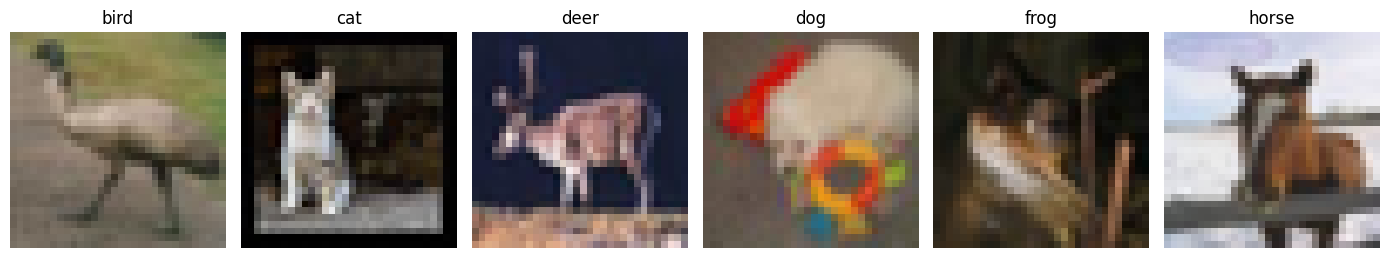

In [15]:
# Visualisation d'une image par classe
plt.figure(figsize=(14, 4))
for class_idx, class_name in enumerate(class_names):
    sample_idx = np.where(np.argmax(y_train, axis=1) == class_idx)[0][0]
    plt.subplot(1, len(class_names), class_idx + 1)
    plt.imshow(x_train[sample_idx])
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2) Modèle de base : MLP

Entrées vectorisées :   
images applaties ($32 \times 32 \times 3 = 3072$ entrées)   
les valeurs peuvent varier fortement d'un pixel à l'autre selon les images.   
La BatchNormalization va recentrer tout cela à chaque passage.   

Profondeur : Avec des couches de 1024 et 512 neurones, le réseau commence à avoir une certaine complexité.   
La normalisation aide à ce que les gradients ne s'essoufflent pas trop vite pendant la descente de gradient.

In [ ]:
# # Définition et entraînement du MLP
# mlp_model = keras.Sequential(
#     [
#         layers.Input(shape=(32 * 32 * 3,)),

#         # Premier bloc Dense
#         layers.Dense(1024),
#         layers.BatchNormalization(), # Normalise avant ou après l'activation
#         layers.Activation('relu'), # Activation après la normalisation
#         layers.Dropout(0.3),

#         # Deuxième bloc Dense
#         layers.Dense(512),
#         layers.BatchNormalization(), # Normalise avant ou après l'activation
#         layers.Activation('relu'), # Activation après la normalisation
#         layers.Dropout(0.3),

#         # Couche de sortie
#         layers.Dense(num_classes, activation='softmax'),
#     ],
#     name='mlp_cifar10',
# )

# mlp_model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy'],
# )

# mlp_history = mlp_model.fit(
#     x_train_mlp,
#     y_train,
#     validation_data=(x_val_mlp, y_val),
#     epochs=12,
#     batch_size=128,
#     verbose=1,
# )

## 3) Modèle convolutionnel : CNN

In [ ]:
# # Définition et entraînement du CNN avec batch normalization et dropout
# cnn_model = keras.Sequential(
#     [
#         layers.Input(shape=(32, 32, 3)),
#         layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         layers.Conv2D(32, (3, 3), activation='relu'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)),
#         layers.Dropout(0.25),

#         layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#         layers.BatchNormalization(),
#         layers.Conv2D(64, (3, 3), activation='relu'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)),
#         layers.Dropout(0.25),

#         layers.Flatten(),
#         layers.Dense(256, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation='softmax'),
#     ],
#     name='cnn_cifar10',
# )

# cnn_model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy'],
# )

# cnn_history = cnn_model.fit(
#     x_train,
#     y_train,
#     validation_data=(x_val, y_val),
#     epochs=15,
#     batch_size=128,
#     verbose=1,
# )

In [ ]:
# # Évaluation quantitative des modèles
# mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test_mlp, y_test_cat, verbose=0)
# cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

# results_df = pd.DataFrame(
#     [
#         {'modele': 'MLP', 'test_loss': mlp_test_loss, 'test_accuracy': mlp_test_acc},
#         {'modele': 'CNN', 'test_loss': cnn_test_loss, 'test_accuracy': cnn_test_acc},
#     ]
# )

# print(results_df)

In [ ]:
# # Courbes d'apprentissage
# def plot_history(history: keras.callbacks.History, title_prefix: str) -> None:
#     """Affiche les courbes de perte et d'accuracy pour un historique Keras."""
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#     axes[0].plot(history.history['loss'], label='train')
#     axes[0].plot(history.history['val_loss'], label='val')
#     axes[0].set_title(f'{title_prefix} - Loss')
#     axes[0].legend()

#     axes[1].plot(history.history['accuracy'], label='train')
#     axes[1].plot(history.history['val_accuracy'], label='val')
#     axes[1].set_title(f'{title_prefix} - Accuracy')
#     axes[1].legend()

#     plt.tight_layout()
#     plt.show()


# plot_history(mlp_history, 'MLP')
# plot_history(cnn_history, 'CNN')

In [ ]:
# # Rapport de classification et matrice de confusion (CNN)
# y_pred_cnn = np.argmax(cnn_model.predict(x_test, verbose=0), axis=1)

# print(classification_report(y_test_raw, y_pred_cnn, target_names=class_names))

# cm = confusion_matrix(y_test_raw, y_pred_cnn)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
# plt.title('Matrice de confusion - CNN')
# plt.xlabel('Prédit')
# plt.ylabel('Vrai')
# plt.show()

Amélioration du modèle

In [18]:
# Callback pour arrêter l'entraînement dès que le modèle n'apprend plus
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,           # Il attend 8 époques sans amélioration avant de stopper
    restore_best_weights=True  # Très important : il recharge les meilleurs poids à la fin
)

In [17]:
# Définition de la stratégie d'augmentation pour améliorer la généralisation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1),
      layers.RandomRotation(0.15), # Un peu plus de rotation
      layers.RandomZoom(0.15),     # Un peu plus de zoom
      layers.RandomContrast(0.2),  # Ajout de variation de contraste
], name="augmentation_layer")

In [20]:
# 1. Définition de l'architecture
cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    # Bloc 1 (32 filtres)
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Bloc 2 (64 filtres)
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Bloc 3 - LE NOUVEAU (128 filtres)
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(512, activation='relu'), # On augmente à 512 neurones
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax'),
])



# 2. COMPILATION (C'est cette ligne qu'il ne faut pas oublier !)
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Divise le learning rate par 2
    patience=4,      # Si pendant 4 époques la val_loss ne baisse pas
    min_lr=1e-6,
    verbose=1
)

# 3. ENTRAÎNEMENT avec les deux callbacks
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=64, # Un batch size plus petit (64 au lieu de 128) aide souvent à mieux généraliser
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 173s 398ms/step - accuracy: 0.3174 - loss: 1.9305 - val_accuracy: 0.2970 - val_loss: 1.7013 - learning_rate: 0.0010
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 165s 391ms/step - accuracy: 0.4177 - loss: 1.5130 - val_accuracy: 0.4240 - val_loss: 1.4457 - learning_rate: 0.0010
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 165s 390ms/step - accuracy: 0.4664 - loss: 1.3722 - val_accuracy: 0.5310 - val_loss: 1.2066 - learning_rate: 0.0010
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 390ms/step - accuracy: 0.5019 - loss: 1.2840 - val_accuracy: 0.5357 - val_loss: 1.2112 - learning_rate: 0.0010
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 200s 386ms/step - accuracy: 0.5354 - loss: 1.2115 - val_accuracy: 0.5143 - val_loss: 1.3103 - learning_rate: 0.0010
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 164s 389ms/step - accuracy: 0.5554 - loss: 1.1649 - val_accuracy: 0.4883 - val_loss: 1.4630 - learning_rate: 0.0010
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - a

## 4) Export du modèle entraîné

In [21]:
# Test rapide pour voir si l'objet existe encore
try:
    print(f"Modèle trouvé ! Nombre de couches : {len(cnn_model.layers)}")
except NameError:
    print("Le kernel a été réinitialisé : le modèle 'cnn_model' n'existe plus en mémoire.")

Modèle trouvé ! Nombre de couches : 21


In [22]:
# On remonte d'un cran vers la racine du projet
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"✅ Chemin ajouté : {project_root}")

✅ Chemin ajouté : /content


In [24]:
def save_trained_model(model: Any, export_path: Path | str) -> None:
    """Sauvegarde un modèle Keras au format .keras."""
    path = Path(export_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    model.save(str(path))

In [25]:
# Détermination du chemin racine du projet
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
export_dir = project_root / 'exports'
export_dir.mkdir(exist_ok=True)

# Recherche du prochain numéro de version disponible
version = 1
while (export_dir / f'cifar10_cnn_v{version}.keras').exists():
    version += 1

export_path = export_dir / f'cifar10_cnn_v{version}.keras'

# Sauvegarde finale
save_trained_model(cnn_model, export_path)
print(f"✅ Nouveau modèle exporté sous : {export_path.name}")

✅ Nouveau modèle exporté sous : cifar10_cnn_v1.keras


In [26]:
import json

# Définit tes meilleurs paramètres et résultats
best_params = {
    "model_name": export_path.name,
    "architecture": "CNN",
    "optimizer": "adam",
    "batch_size": 128,
    "epochs_trained": len(cnn_history.history['loss']),
    "val_accuracy": float(max(cnn_history.history['val_accuracy'])),
    "val_loss": float(min(cnn_history.history['val_loss'])),
    "data_augmentation": True,
    "dropout_rate": 0.5
}

# On change l'extension .keras en .json
json_path = export_path.with_suffix('.json')

with open(json_path, 'w') as f:
    json.dump(best_params, f, indent=4)

print(f"✅ Paramètres enregistrés sous : {json_path.name}")

✅ Paramètres enregistrés sous : cifar10_cnn_v1.json


In [27]:
from google.colab import files
import os

# On remonte au bon chemin si nécessaire
file_to_download = "exports/cifar10_cnn_v1.keras"
json_to_download = "exports/cifar10_cnn_v1.json"

if os.path.exists(file_to_download):
    files.download(file_to_download)
if os.path.exists(json_to_download):
    files.download(json_to_download)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# Évaluation finale sur le Test Set (données jamais vues)
test_loss, test_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"🎯 Résultat final sur le Test Set :")
print(f"   - Précision (Accuracy) : {test_acc:.2%}")
print(f"   - Perte (Loss)         : {test_loss:.4f}")

# Mise à jour du dictionnaire pour l'export JSON
best_params["test_accuracy"] = float(test_acc)
best_params["test_loss"] = float(test_loss)

🎯 Résultat final sur le Test Set :
   - Précision (Accuracy) : 74.23%
   - Perte (Loss)         : 0.7327


## Cartouche final
- Projet: Classification d'images CIFAR-10 (MLP vs CNN).
- Exécution: compatible Google Colab (CPU/GPU).
- Source des données: https://www.cs.toronto.edu/~kriz/cifar.html
- Sorties attendues: métriques de test, courbes d'apprentissage, matrice de confusion.
- Piste d'amélioration: data augmentation, scheduler de learning rate, transfert d'apprentissage (ResNet/EfficientNet).